#### **Lab 9. SVD(특이값 분해)를 이용한 이미지 압축**

모든 행렬은 로 분해됩니다. 의 중요도 순으로 데이터를 남겨 정보를 압축합니다.

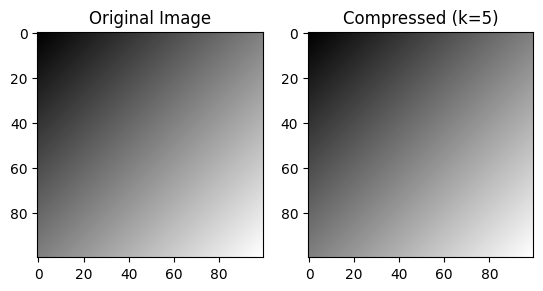

In [ ]:
# 0~255 사이의 그라데이션 이미지 생성 (100x100)
img = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        img[i, j] = i + j # 대각선 그라데이션 패턴

# SVD 수행
U, S, Vt = np.linalg.svd(img)

# 상위 k개의 특이값만 사용하여 이미지 복원
k = 5
reconstructed_img = np.dot(U[:, :k] * S[:k], Vt[:k, :])

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img, cmap='gray')
plt.title(f"Compressed (k={k})")
plt.show()

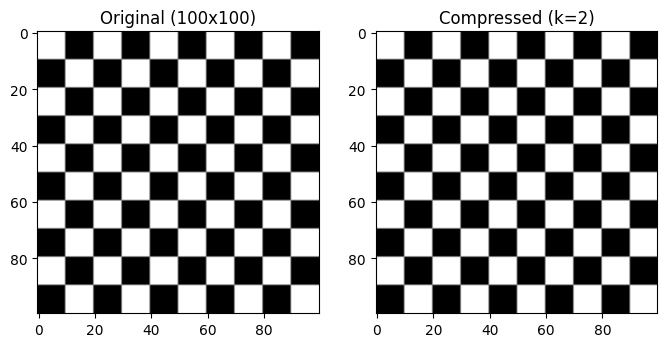

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 이미지 압축 (Image Compression)
# 100x100 크기의 체스판 패턴 생성 (데이터 행렬 생성)
img = np.kron([[1, 0] * 5, [0, 1] * 5] * 5, np.ones((10, 10)))

# SVD(특이값 분해) 수행
# U: 왼쪽 특이벡터, S: 특이값(벡터), Vt: 오른쪽 특이벡터(전치)
U, S, Vt = np.linalg.svd(img)

# 상위 k개의 특이값만 사용하여 이미지 복원 (데이터 압축)
k = 2
# U의 k열, S의 k개 원소(대각행렬화), Vt의 k행을 행렬 곱함
img_reconstructed = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

# 시각화 설정
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original (100x100)")
plt.imshow(img, cmap='gray') # 원본 출력

plt.subplot(1, 2, 2)
plt.title(f"Compressed (k={k})")
plt.imshow(img_reconstructed, cmap='gray') # 압축 복원본 출력
plt.show()

#### **예시 1 해석: 이미지 압축**
- **원리**: 행렬의 정보량을 결정하는 특이값(S) 중 가장 큰 $k$개만 선택하여 데이터를 재구성합니다.
- **결과**: 원본 이미지의 10,000개 픽셀 대신 약 400여 개의 데이터($100 \times k + k + k \times 100$)만으로도 체스판의 반복적인 패턴을 완벽히 복원할 수 있음을 보여줍니다.

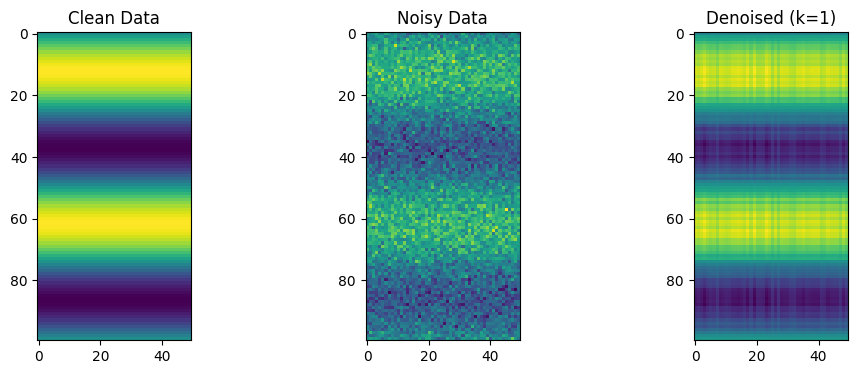

In [2]:
# 2. 데이터 노이즈 제거 (Noise Reduction)
np.random.seed(42) # 결과 재현을 위한 시드 설정
t = np.linspace(0, 1, 100) # 0에서 1 사이를 100등분
# 깨끗한 신호 행렬 생성 (100x50 크기의 반복되는 사인 패턴)
clean_data = np.sin(2 * np.pi * 2 * t).reshape(-1, 1) @ np.ones((1, 50))
# 무작위 노이즈 생성 및 추가 (평균 0, 표준편차 0.5)
noisy_data = clean_data + np.random.normal(0, 0.5, clean_data.shape)

# SVD 수행 (Reduced SVD 옵션 사용)
U, S, Vt = np.linalg.svd(noisy_data, full_matrices=False)

# k=1 (가장 지배적인 주성분 신호만 추출하여 노이즈 제거)
k = 1
denoised_data = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

# 결과 비교 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title("Clean Data"); plt.imshow(clean_data) # 원본 신호
plt.subplot(1, 3, 2); plt.title("Noisy Data"); plt.imshow(noisy_data) # 노이즈 섞인 신호
plt.subplot(1, 3, 3); plt.title("Denoised (k=1)"); plt.imshow(denoised_data) # 복원된 신호
plt.show()

#### **예시 2 해석: 노이즈 제거**
- **원리**: 실제 데이터의 규칙적인 패턴은 큰 특이값에 모이고, 무작위 노이즈는 여러 개의 작은 특이값들에 흩어집니다.
- **결과**: $k=1$인 주성분만 남기고 나머지를 버림으로써, 노이즈가 섞여 변질되었던 데이터에서 원본의 깨끗한 구조를 다시 찾아낼 수 있습니다.

In [3]:
# 3. 추천 시스템 (Latent Factor Discovery)
# 행: 사용자(4명), 열: 영화 장르 [액션, SF, 로맨스, 코미디]
user_item_matrix = np.array([
    [5, 5, 0, 0], # 사용자 A (액션/SF 선호)
    [5, 4, 1, 0], # 사용자 B (액션/SF 선호)
    [0, 1, 4, 5], # 사용자 C (로맨스/코미디 선호)
    [1, 0, 5, 4]  # 사용자 D (로맨스/코미디 선호)
], dtype=float)

# SVD 수행하여 잠재 특징(Latent Factors) 추출
U, S, Vt = np.linalg.svd(user_item_matrix)

# 결과 출력
print("Singular Values (특이값 - 데이터의 중요도):", S.round(2))
# U 행렬의 상위 2개 열을 통해 사용자의 취향 그룹(잠재 요인) 확인
print("\nUser Latent Factors (사용자별 잠재 특징 요약):\n", U[:, :2].round(2))

Singular Values (특이값 - 데이터의 중요도): [10.06  8.5   1.59  0.  ]

User Latent Factors (사용자별 잠재 특징 요약):
 [[-0.58 -0.47]
 [-0.57 -0.36]
 [-0.41  0.58]
 [-0.42  0.57]]


#### **예시 3 해석: 잠재 특징 분석**
- **원리**: 사용자-아이템 행렬을 분해하여 데이터 이면에 숨겨진 '잠재 요인(Latent Factor)'을 찾아냅니다.
- **결과**: 특이값 중 상위 2개가 지배적이며, 이를 통해 사용자 A, B는 '장르 그룹 1'에, C, D는 '장르 그룹 2'에 가깝다는 것을 수학적으로 군집화할 수 있습니다. 이는 넷플릭스 등의 추천 알고리즘의 핵심 원리입니다.

#### **`np.linalg.svd()` 메서드 상세 분석**

Python의 `numpy` 라이브러리에서 제공하는 `np.linalg.svd(a, full_matrices=True, compute_uv=True)` 함수는 행렬을 특이값 분해하는 핵심 도구입니다.

**1. 주요 파라미터**
*   **`a`**: 분해할 $m \times n$ 크기의 입력 행렬입니다.
*   **`full_matrices` (bool)**:
    *   `True` (기본값): $U$를 $(m, m)$, $V^T$를 $(n, n)$ 크기로 반환합니다.
    *   `False`: **Reduced SVD**를 수행합니다. $U$를 $(m, k)$, $V^T$를 $(k, n)$ 크기로 반환합니다 (여기서 $k = \min(m, n)$). 메모리 절약을 위해 자주 사용됩니다.
*   **`compute_uv` (bool)**:
    *   `True` (기본값): $U, S, V^T$ 세 개를 모두 반환합니다.
    *   `False`: 특이값 $S$만 계산하여 반환합니다. (속도가 더 빠름)

**2. 반환 값 (Returns)**
*   **`U`**: 왼쪽 특이 벡터 행렬 ($m \times m$ 또는 $m \times k$).
*   **`S`**: 특이값들을 담고 있는 **1차원 벡터** ($k$ 크기).
    *   주의: 행렬 형태가 아니라 내림차순으로 정렬된 벡터로 반환되므로, 행렬 곱을 하려면 `np.diag(S)`를 사용해야 합니다.
*   **`Vh`**: 오른쪽 특이 벡터 행렬의 **전치(Transpose)** 상태 ($n \times n$ 또는 $k \times n$).
    *   함수 이름의 'h'는 Hermitian(또는 Transpose)을 의미합니다.

**3. 수학적 복원 코드 패턴**
```python
# SVD 수행
U, S, Vt = np.linalg.svd(A, full_matrices=False)

# 원본 복원 (A = U * Sigma * Vt)
# S가 벡터이므로 diag로 행렬화 시켜줘야 함
Sigma = np.diag(S)
restored = U @ Sigma @ Vt
```

#### **SVD (특이값 분해)의 수학적 설명**

특이값 분해(Singular Value Decomposition, SVD)는 임의의 $m \times n$ 크기의 행렬 $A$를 세 개의 행렬의 곱으로 분해하는 방법입니다. 즉,

$$A = U \Sigma V^T$$

여기서 각 행렬의 의미는 다음과 같습니다:

1.  **$A$**: 분해하려는 $m \times n$ 크기의 원본 행렬입니다.

2.  **$U$**: $m \times m$ 크기의 직교 행렬(orthogonal matrix)입니다. $U$의 열 벡터들은 $A A^T$의 고유벡터(eigenvector)들로 구성되며, 이들을 왼쪽 특이 벡터(left singular vector)라고 합니다. 직교 행렬이므로 $U^T U = I$를 만족합니다.

3.  **$\Sigma$ (시그마)**: $m \times n$ 크기의 직사각 대각 행렬(rectangular diagonal matrix)입니다. 대각선 성분에는 0이 아닌 양수 값인 **특이값(singular value)** $\sigma_1, \sigma_2, ..., \sigma_r$ (여기서 $r = \text{min}(m, n)$)이 크기 순서대로 내림차순으로 배열되어 있습니다. 나머지 성분은 모두 0입니다. 이 특이값들은 행렬 $A$의 '중요도'를 나타내며, 일반적으로 $\sigma_1 \ge \sigma_2 \ge ... \ge \sigma_r > 0$ 입니다.
    특이값은 $A^T A$ (또는 $A A^T$)의 고유값(eigenvalue)의 양의 제곱근으로 계산됩니다. 즉, $\sigma_i = \sqrt{\lambda_i}$ 입니다.

4.  **$V^T$**: $V$는 $n \times n$ 크기의 직교 행렬이며, $V^T$는 $V$의 전치(transpose) 행렬입니다. $V$의 열 벡터들은 $A^T A$의 고유벡터들로 구성되며, 이들을 오른쪽 특이 벡터(right singular vector)라고 합니다. $V^T V = I$를 만족합니다.

#### **SVD의 특징 및 활용**

*   **차원 축소 (Dimensionality Reduction)**: 특이값의 크기 순서에 따라 중요한 정보를 담고 있는 부분을 선택하여 데이터를 압축하거나 차원을 축소할 수 있습니다. 상위 $k$개의 큰 특이값과 이에 해당하는 특이 벡터들만을 사용하여 행렬을 근사하면, 원본 행렬의 중요한 특징을 유지하면서 데이터의 크기를 크게 줄일 수 있습니다. 이는 이미지 압축, 추천 시스템, 잠재 의미 분석(LSA) 등에 널리 사용됩니다.

*   **행렬의 랭크 (Rank) 결정**: 0이 아닌 특이값의 개수는 행렬 $A$의 랭크와 같습니다.

*   **일반화된 역행렬 (Generalized Inverse) 계산**: SVD를 사용하여 모든 행렬에 대해 역행렬과 유사한 개념인 무어-펜로즈 역행렬(Moore-Penrose pseudoinverse)을 계산할 수 있습니다.

*   **데이터 노이즈 제거**: 작은 특이값들을 제거함으로써 데이터에 포함된 노이즈를 효과적으로 제거할 수 있습니다.

#### **이미지 압축에서의 SVD**

이미지 데이터는 픽셀 값을 포함하는 행렬로 표현될 수 있습니다. SVD를 적용하여 $A = U \Sigma V^T$로 분해한 후, 상위 $k$개의 가장 큰 특이값과 해당 특이 벡터들만을 사용하여 근사된 행렬 $A_k$를 생성합니다.

$$A_k = U_k \Sigma_k V_k^T$$

여기서 $U_k$는 $U$의 첫 $k$개 열 벡터, $\Sigma_k$는 $\Sigma$의 첫 $k$개 특이값을 포함하는 $k \times k$ 대각 행렬, $V_k^T$는 $V^T$의 첫 $k$개 행 벡터로 구성됩니다. 이 $A_k$는 원본 이미지 $A$의 주요 특징을 보존하면서도 훨씬 적은 데이터로 이미지를 표현할 수 있게 합니다.

#### **고윳값 (Eigenvalue)과 고유벡터 (Eigenvector)**

정방행렬 $A$에 대해 다음 식을 만족하는 0이 아닌 벡터 $x$와 스칼라 $\lambda$가 존재할 때,

$$Ax = \lambda x$$

*   벡터 $x$를 행렬 $A$의 **고유벡터(eigenvector)**라고 합니다.
*   스칼라 $\lambda$를 행렬 $A$의 **고윳값(eigenvalue)**이라고 합니다.

**설명:**
*   고유벡터 $x$는 행렬 $A$에 의해 선형 변환될 때, 방향은 변하지 않고 스칼라 $\lambda$만큼만 크기가 변하는 특별한 벡터입니다.
*   고윳값 $\lambda$는 해당 고유벡터 $x$가 행렬 $A$에 의해 얼마나 스케일링되는지를 나타내는 값입니다.
*   고윳값과 고유벡터는 행렬의 특성을 파악하고, 시스템의 안정성 분석, 주성분 분석(PCA)과 같은 차원 축소, 진동 모드 분석 등 다양한 분야에서 활용됩니다.
*   일반적으로 $n \times n$ 행렬은 최대 $n$개의 고윳값과 고유벡터 쌍을 가질 수 있습니다.

#### **역행렬과 고유벡터의 관계**

역행렬(Inverse Matrix)과 고유벡터(Eigenvector)는 행렬의 중요한 특성을 나타내는 개념들이지만, 직접적인 함수 관계보다는 서로의 존재 조건이나 변환 특성에서 연관성을 찾을 수 있습니다.

1.  **역행렬의 존재 여부와 고윳값 (Eigenvalue) 0**:
    가장 중요한 관계는 정방행렬 $A$가 **역행렬을 가질 조건이 '0이 고윳값이 아닐 때'** 라는 것입니다.
    *   만약 행렬 $A$의 고윳값 중 하나가 $\lambda = 0$이라면, 특성 방정식 $\text{det}(A - \lambda I) = 0$에 의해 $\text{det}(A - 0I) = \text{det}(A) = 0$이 됩니다. 행렬식이 0인 행렬은 역행렬을 갖지 않습니다 (특이 행렬, Singular Matrix).
    *   반대로, 행렬 $A$가 역행렬을 가진다면, $\text{det}(A) \neq 0$이므로 $\lambda = 0$은 $A$의 고윳값이 될 수 없습니다.
    
    **요약:** 행렬이 역행렬을 가지려면, 모든 고윳값이 0이 아니어야 합니다.

2.  **역행렬의 고유벡터와 고윳값**:
    만약 정방행렬 $A$가 역행렬을 가지고, $x$가 고윳값 $\lambda$에 해당하는 $A$의 고유벡터라고 합시다. 즉, $Ax = \lambda x$ ($x \neq 0$, $\lambda \neq 0$) 입니다.
    
    이 식의 양변에 $A^{-1}$를 곱하면:
    $$A^{-1}(Ax) = A^{-1}(\lambda x)$$
    $$(A^{-1}A)x = \lambda (A^{-1}x)$$
    $$Ix = \lambda (A^{-1}x)$$
    $$x = \lambda (A^{-1}x)$$
    
    $\lambda \neq 0$이므로 양변을 $\lambda$로 나누면:
    $$A^{-1}x = \frac{1}{\lambda} x$$
    
    **요약:** 행렬 $A$의 고유벡터 $x$는 $A$의 역행렬 $A^{-1}$의 고유벡터이기도 합니다. 이때 $A^{-1}$에 대한 고윳값은 $A$에 대한 고윳값 $\lambda$의 역수($1/\lambda$)가 됩니다. 이 관계는 $\lambda \neq 0$일 때만 성립하며, 이는 $A$가 역행렬을 가질 때만 가능한 조건과 일치합니다.

#### **고윳값 (Eigenvalue)과 고유벡터 (Eigenvector) 계산 방법**

정방행렬 $A$에 대해 고윳값 $\lambda$와 고유벡터 $x$는 다음 식을 만족합니다.

$$Ax = \lambda x$$

이 식을 다시 정리하면 다음과 같습니다.

$$Ax - \lambda x = 0$$
$$Ax - \lambda I x = 0$$
$$(A - \lambda I)x = 0$$

여기서 $I$는 $A$와 같은 크기의 단위행렬(identity matrix)입니다. 이 방정식이 0이 아닌 고유벡터 $x$ 해를 가지려면, 행렬 $(A - \lambda I)$가 역행렬을 가지지 않아야 합니다. 즉, 행렬 $(A - \lambda I)$의 행렬식(determinant)이 0이 되어야 합니다.

$$\text{det}(A - \lambda I) = 0$$

이 방정식을 **특성 방정식(Characteristic Equation)**이라고 합니다. 특성 방정식을 풀면 고윳값 $\lambda$를 얻을 수 있습니다.

**계산 단계:**

1.  **특성 방정식 설정**: 주어진 정방행렬 $A$에 대해 $(A - \lambda I)$를 계산합니다.
    예를 들어, $A = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$ 라면, $A - \lambda I = \begin{pmatrix} a-\lambda & b \\ c & d-\lambda
\end{pmatrix}$ 가 됩니다.

2.  **행렬식 계산**: $\text{det}(A - \lambda I) = 0$ 방정식을 풉니다.
    2x2 행렬의 경우, $(a-\lambda)(d-\lambda) - bc = 0$ 이 됩니다. 이 2차 방정식을 풀면 $\lambda$에 대한 해가 나옵니다. 이것이 바로 고윳값들입니다.

3.  **고유벡터 계산**: 각 고윳값 $\lambda_i$에 대해 $(A - \lambda_i I)x = 0$ 방정식을 다시 풀어서 해당하는 고유벡터 $x_i$를 구합니다. 이 때, 고유벡터는 0이 아닌 벡터이며, 스칼라배에 대해 여러 해가 존재할 수 있으므로 보통 크기가 1인 단위 벡터로 정규화하여 사용합니다.

**예시 (2x2 행렬):**

행렬 $A = \begin{pmatrix} 2 & 1 \\ 1 & 2
\end{pmatrix}$ 에 대한 고윳값과 고유벡터를 구해봅시다.

1.  **특성 방정식**: $A - \lambda I = \begin{pmatrix} 2-\lambda & 1 \\ 1 & 2-\lambda
\end{pmatrix}$

2.  **행렬식 계산**: $\text{det}(A - \lambda I) = (2-\lambda)(2-\lambda) - (1)(1) = (2-\lambda)^2 - 1 = 0$
    $(2-\lambda)^2 = 1 \implies 2-\lambda = \pm 1$
    *   $2-\lambda = 1 \implies \lambda_1 = 1$
    *   $2-\lambda = -1 \implies \lambda_2 = 3$
    따라서 고윳값은 $\lambda_1 = 1$과 $\lambda_2 = 3$ 입니다.

3.  **고유벡터 계산**:
    *   **$\lambda_1 = 1$ 일 때**: $(A - 1I)x = 0 \implies \begin{pmatrix} 1 & 1 \\ 1 & 1
\end{pmatrix} \begin{pmatrix} x_1 \\ x_2
\end{pmatrix} = \begin{pmatrix} 0 \\ 0
\end{pmatrix}$
        $x_1 + x_2 = 0 \implies x_2 = -x_1$. 따라서 고유벡터는 $c\begin{pmatrix} 1 \\ -1
\end{pmatrix}$ 형태입니다. (예: $\begin{pmatrix} 1 \\ -1
\end{pmatrix}$)
    *   **$\lambda_2 = 3$ 일 때**: $(A - 3I)x = 0 \implies \begin{pmatrix} -1 & 1 \\ 1 & -1
\end{pmatrix} \begin{pmatrix} x_1 \\ x_2
\end{pmatrix} = \begin{pmatrix} 0 \\ 0
\end{pmatrix}$
        $-x_1 + x_2 = 0 \implies x_2 = x_1$. 따라서 고유벡터는 $c\begin{pmatrix} 1 \\ 1
\end{pmatrix}$ 형태입니다. (예: $\begin{pmatrix} 1 \\ 1
\end{pmatrix}$)

#### **직교행렬 (Orthogonal Matrix)**

직교행렬 $Q$는 전치행렬 $Q^T$와 역행렬 $Q^{-1}$이 같은 정방행렬(square matrix)을 의미합니다. 즉, $Q^T Q = Q Q^T = I$를 만족합니다. 여기서 $I$는 단위행렬(identity matrix)입니다.

**주요 특징:**
*   직교행렬의 열 벡터(또는 행 벡터)들은 서로 직교(orthogonal)하며, 각각의 크기(norm)는 1인 단위 벡터(unit vector)입니다. 이러한 벡터들을 정규직교 벡터(orthonormal vector)라고 합니다.
*   직교행렬은 벡터의 길이나 내적을 보존하는 변환(예: 회전, 반사)을 나타냅니다. 따라서 기하학적 변환에서 중요한 역할을 합니다.
*   직교행렬의 행렬식(determinant)은 항상 $1$ 또는 $-1$ 입니다.

#### **고윳값 (Eigenvalue)과 고유벡터 (Eigenvector)**

정방행렬 $A$에 대해 다음 식을 만족하는 0이 아닌 벡터 $x$와 스칼라 $\lambda$가 존재할 때,

$$Ax = \lambda x$$

*   벡터 $x$를 행렬 $A$의 **고유벡터(eigenvector)**라고 합니다.
*   스칼라 $\lambda$를 행렬 $A$의 **고윳값(eigenvalue)**이라고 합니다.

**설명:**
*   고유벡터 $x$는 행렬 $A$에 의해 선형 변환될 때, 방향은 변하지 않고 스칼라 $\lambda$만큼만 크기가 변하는 특별한 벡터입니다.
*   고윳값 $\lambda$는 해당 고유벡터 $x$가 행렬 $A$에 의해 얼마나 스케일링되는지를 나타내는 값입니다.
*   고윳값과 고유벡터는 행렬의 특성을 파악하고, 시스템의 안정성 분석, 주성분 분석(PCA)과 같은 차원 축소, 진동 모드 분석 등 다양한 분야에서 활용됩니다.
*   일반적으로 $n \times n$ 행렬은 최대 $n$개의 고윳값과 고유벡터 쌍을 가질 수 있습니다.

#### **직교행렬 (Orthogonal Matrix)**

직교행렬 $Q$는 전치행렬 $Q^T$와 역행렬 $Q^{-1}$이 같은 정방행렬(square matrix)을 의미합니다. 즉, $Q^T Q = Q Q^T = I$를 만족합니다. 여기서 $I$는 단위행렬(identity matrix)입니다.

**주요 특징:**
*   직교행렬의 열 벡터(또는 행 벡터)들은 서로 직교(orthogonal)하며, 각각의 크기(norm)는 1인 단위 벡터(unit vector)입니다. 이러한 벡터들을 정규직교 벡터(orthonormal vector)라고 합니다.
*   직교행렬은 벡터의 길이나 내적을 보존하는 변환(예: 회전, 반사)을 나타냅니다. 따라서 기하학적 변환에서 중요한 역할을 합니다.
*   직교행렬의 행렬식(determinant)은 항상 $1$ 또는 $-1$ 입니다.

#### **Lab 10. PCA (주성분 분석) 파이프라인 완성**

데이터의 공분산 행렬을 구하고, 고유벡터 축으로 데이터를 투영하여 차원을 축소합니다.

In [ ]:
# [데이터 생성] 키와 몸무게처럼 상관관계가 있는 데이터
np.random.seed(0)
X = np.dot(np.random.rand(2, 2), np.random.randn(2, 200)).T

# 1. 중심화 (Mean Centering)
X_centered = X - X.mean(axis=0)

# 2. 공분산 행렬 계산
cov_mat = np.cov(X_centered.T)

# 3. 고유값 분해
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

# 4. 정렬 (설명력이 높은 순서대로)
idx = eigen_vals.argsort()[::-1]
eigen_vecs = eigen_vecs[:, idx]

# 5. 투영 (Projection) - 2차원을 1차원으로 축소
# 가장 중요한 주성분(PC1) 하나만 선택
pc1 = eigen_vecs[:, 0]
X_projected = X_centered.dot(pc1)

print("원본 데이터 Shape:", X.shape)
print("차원 축소된 데이터 Shape:", X_projected.shape)
# (200, 2) -> (200,) 로 압축됨

원본 데이터 Shape: (200, 2)
차원 축소된 데이터 Shape: (200,)


#### **PCA (Principal Component Analysis: 주성분 분석)**

주성분 분석(PCA)은 고차원 데이터를 저차원 공간으로 변환하여 데이터의 패턴을 찾고, 시각화하며, 노이즈를 제거하는 데 사용되는 대표적인 차원 축소(Dimensionality Reduction) 기법입니다.

**PCA의 목적:**
*   **데이터 압축**: 원본 데이터의 정보를 최대한 보존하면서 차원을 줄입니다.
*   **데이터 시각화**: 고차원 데이터를 2차원 또는 3차원으로 변환하여 시각적으로 이해하기 쉽게 만듭니다.
*   **노이즈 제거**: 데이터에 포함된 불필요한 노이즈를 줄여줍니다.
*   **특징 추출**: 데이터의 주요 특징을 나타내는 새로운 변수(주성분)를 추출합니다.

**PCA의 작동 원리 (수학적 배경):**
PCA는 데이터의 **분산(Variance)**을 최대한 보존하는 새로운 직교 좌표축(주성분)을 찾는 것을 목표로 합니다. 이 과정은 주로 **공분산 행렬(Covariance Matrix)**의 **고윳값(Eigenvalue)**과 **고유벡터(Eigenvector)**를 이용합니다.

PCA의 주요 단계는 다음과 같습니다:

1.  **데이터 중심화 (Mean Centering)**: 각 특성(feature)에서 해당 특성의 평균을 빼서 데이터를 원점을 중심으로 이동시킵니다. 이는 공분산 행렬을 더 쉽게 계산하고 해석하기 위함입니다.
    $$X_{centered} = X - \bar{X}$$

2.  **공분산 행렬 계산**: 중심화된 데이터의 공분산 행렬을 계산합니다. 공분산 행렬은 각 특성 간의 선형 관계와 분산을 나타냅니다.
    $$\text{Cov}(X_{centered}) = \frac{1}{n-1} X_{centered}^T X_{centered}$$

3.  **고유값 분해 (Eigenvalue Decomposition)**: 계산된 공분산 행렬의 고윳값과 고유벡터를 구합니다. 이 단계가 PCA의 핵심입니다.
    $$ \text{Cov}(X_{centered}) \cdot v = \lambda \cdot v $$
    *   **고윳값 ($\lambda$)**: 각 고유벡터(주성분)가 설명하는 데이터의 분산량(정보량)을 나타냅니다. 고윳값이 클수록 해당 고유벡터가 더 많은 정보를 담고 있다는 의미입니다.
    *   **고유벡터 ($v$)**: 새로운 좌표축인 **주성분(Principal Component)**을 정의합니다. 각 고유벡터는 서로 직교하며, 데이터의 분산 방향을 나타냅니다.

4.  **고윳값 정렬 및 주성분 선택**: 고윳값을 크기 순서대로 내림차순으로 정렬합니다. 가장 큰 고윳값에 해당하는 고유벡터가 첫 번째 주성분(PC1), 두 번째로 큰 고윳값에 해당하는 고유벡터가 두 번째 주성분(PC2)이 됩니다. 데이터의 차원을 축소하려면, 상위 $k$개의 고윳값에 해당하는 고유벡터들을 선택합니다.

5.  **데이터 투영 (Projection)**: 선택된 주성분(고유벡터들)을 사용하여 원본 데이터를 새로운 저차원 공간으로 투영합니다. 이는 원본 데이터를 주성분 행렬과 곱함으로써 이루어집니다.
    $$X_{projected} = X_{centered} \cdot W$$
    여기서 $W$는 선택된 $k$개의 고유벡터를 열 벡터로 하는 행렬입니다.

**PCA의 활용:**
*   얼굴 인식, 이미지 압축, 유전자 데이터 분석 등 다양한 분야에서 차원 축소와 특징 추출에 사용됩니다.
*   머신러닝 모델의 입력 차원을 줄여 과적합을 방지하고 모델의 학습 속도를 향상시킬 수 있습니다.

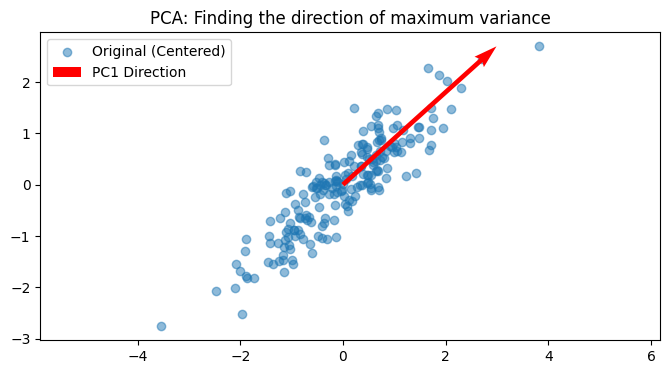

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 기본적인 2차원 데이터의 1차원 축소
np.random.seed(42)
# 대각선 방향으로 길게 늘어진 데이터 생성
X = np.dot(np.random.rand(2, 2), np.random.randn(2, 200)).T

# 데이터 중심화 (Mean Centering)
X_centered = X - np.mean(X, axis=0)

# 공분산 행렬 계산 및 고유값 분해
cov_matrix = np.cov(X_centered.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_matrix)

# 첫 번째 주성분(PC1)으로 투영
pc1 = eigen_vecs[:, np.argmax(eigen_vals)]
X_pca = X_centered @ pc1

# 시각화
plt.figure(figsize=(8, 4))
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5, label='Original (Centered)')
plt.quiver(0, 0, pc1[0], pc1[1], color='r', scale=3, label='PC1 Direction')
plt.title("PCA: Finding the direction of maximum variance")
plt.legend()
plt.axis('equal')
plt.show()

#### **PCA 예시 1 해석: 최대 분산 방향 찾기**
- **원리**: PCA는 데이터가 가장 넓게 퍼져 있는 방향(분산이 최대인 지점)을 첫 번째 주성분축으로 설정합니다.
- **결과**: 붉은색 화살표(PC1)가 데이터의 주된 흐름을 정확히 가리키고 있습니다. 이 축으로 데이터를 투영하면 2차원 데이터를 정보 손실을 최소화하며 1차원으로 줄일 수 있습니다.

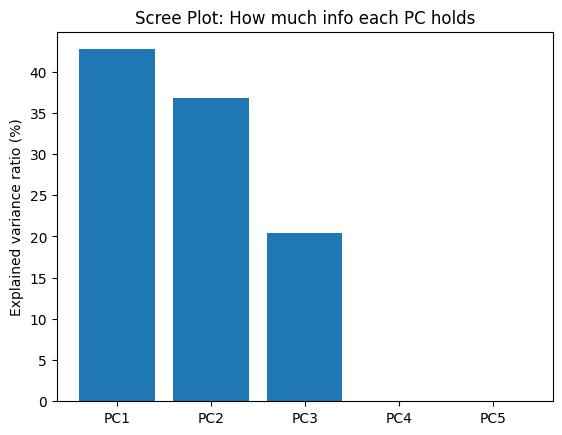

In [5]:
# 2. 설명된 분산량 분석 (Explained Variance Ratio)
# 5개의 변수를 가진 가상의 데이터 생성
np.random.seed(0)
raw_data = np.random.randn(100, 5)
# 변수 간 상관관계 강제로 부여
raw_data[:, 2] = raw_data[:, 0] * 0.8 + raw_data[:, 1] * 0.2
raw_data[:, 3] = raw_data[:, 0] * 0.1 + raw_data[:, 1] * 0.9

# 공분산 행렬 및 고유값 계산
cov_mat = np.cov(raw_data.T)
eigen_vals, _ = np.linalg.eig(cov_mat)

# 고유값 정렬 및 비율 계산
eigen_vals = sorted(eigen_vals, reverse=True)
var_exp = [(i / sum(eigen_vals)) * 100 for i in eigen_vals]

# Scree Plot 시각화
plt.bar(range(1, 6), var_exp, tick_label=[f'PC{i}' for i in range(1, 6)])
plt.ylabel('Explained variance ratio (%)')
plt.title('Scree Plot: How much info each PC holds')
plt.show()

#### **PCA 예시 2 해석: 정보 보유량(분산) 확인**
- **원리**: 각 주성분이 전체 데이터의 정보를 얼마나 담고 있는지는 고유값($\lambda$)의 크기에 비례합니다.
- **결과**: 그래프에서 PC1과 PC2가 대부분의 정보를 차지하는 것을 볼 수 있습니다. 이는 원래 5개의 변수가 있었지만, 실제로는 2개의 주성분만으로도 전체 데이터의 80~90% 이상을 설명할 수 있음을 의미합니다.

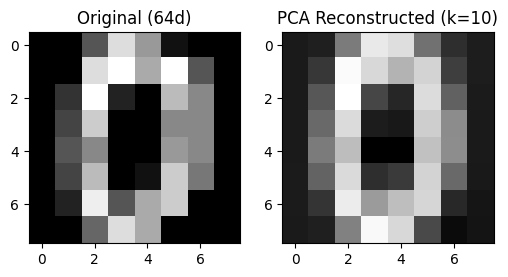

In [6]:
# 3. 노이즈 제거 및 복원 (Feature Extraction)
from sklearn.datasets import load_digits
digits = load_digits()
X_digits = digits.data # 8x8 이미지 (64차원)

# 중심화 및 SVD를 이용한 PCA 수행 (주성분 10개만 사용)
X_mean = np.mean(X_digits, axis=0)
X_centered = X_digits - X_mean
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# 64차원 -> 10차원으로 압축 후 다시 64차원으로 복원
k = 10
X_reduced = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
X_recovered = X_reduced + X_mean

# 결과 시각화
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1); plt.title("Original (64d)"); plt.imshow(X_digits[0].reshape(8, 8), cmap='gray')
plt.subplot(1, 2, 2); plt.title(f"PCA Reconstructed (k={k})"); plt.imshow(X_recovered[0].reshape(8, 8), cmap='gray')
plt.show()

#### **PCA 예시 3 해석: 고차원 데이터(이미지) 특징 추출**
- **원리**: 64개의 픽셀(변수) 중 의미 없는 세부 노이즈를 버리고, 숫자의 형태를 결정짓는 핵심적인 10개의 주성분축만 남깁니다.
- **결과**: 데이터 크기를 약 1/6로 줄였음에도 불구하고(k=10), 원래 숫자가 무엇인지 식별하는 데 문제가 없을 정도로 중요한 특징들이 잘 보존되었습니다.

#### **공분산 행렬 (Covariance Matrix)**

공분산 행렬은 여러 개의 특성(Feature)들 사이의 **공분산(Covariance)**을 행렬 형태로 나타낸 것입니다. 데이터의 형태가 어떻게 퍼져 있는지, 그리고 변수들 사이에 어떤 선형적 관계가 있는지를 파악하는 데 사용됩니다.

**1. 공분산(Covariance)이란?**
두 변수 $X$와 $Y$가 함께 변하는 정도를 나타냅니다.
*   **양의 공분산**: $X$가 커질 때 $Y$도 커지는 경향이 있음.
*   **음의 공분산**: $X$가 커질 때 $Y$는 작아지는 경향이 있음.
*   **0에 가까운 공분산**: 두 변수 사이에 선형적인 관계가 거의 없음.

$$ \text{cov}(X, Y) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n-1} $$

**2. 공분산 행렬의 구조**
$d$개의 특성을 가진 데이터에 대한 공분산 행렬 $\Sigma$는 $d \times d$ 크기의 정방행렬입니다.

$$\Sigma = \begin{pmatrix} \text{var}(X_1) & \text{cov}(X_1, X_2) & \cdots & \text{cov}(X_1, X_d) \\ \text{cov}(X_2, X_1) & \text{var}(X_2) & \cdots & \text{cov}(X_2, X_d) \\ \vdots & \vdots & \ddots & \vdots \\ \text{cov}(X_d, X_1) & \text{cov}(X_d, X_2) & \cdots & \text{var}(X_d) \end{pmatrix}$$

*   **대각 성분**: 각 변수 자신의 **분산(Variance)**을 나타냅니다. (예: $\text{cov}(X_1, X_1) = \text{var}(X_1)$)
*   **비대각 성분**: 서로 다른 두 변수 사이의 **공분산**을 나타냅니다.
*   **대칭 행렬**: $\text{cov}(X_i, X_j) = \text{cov}(X_j, X_i)$ 이므로, 공분산 행렬은 항상 대칭 행렬(Symmetric Matrix)입니다.

**3. 왜 중요한가요?**
*   **PCA와의 관계**: PCA는 이 공분산 행렬을 고유값 분해하여 데이터의 분산이 가장 큰 방향(주성분)을 찾아냅니다.
*   **데이터의 형태 파악**: 공분산 행렬을 통해 데이터가 어느 방향으로 길게 늘어져 있는지(상관관계), 각 축으로 얼마나 퍼져 있는지(분산)를 수학적으로 정의할 수 있습니다.

#### **분산(Variance)과 공분산(Covariance)**

두 개념 모두 데이터의 '퍼짐'을 나타내지만, 대상이 되는 변수의 개수에서 차이가 있습니다.

**1. 분산 (Variance)**
*   **정의**: **하나의 변수**가 그 평균으로부터 얼마나 떨어져 있는지를 나타내는 척도입니다.
*   **의미**: 데이터가 평균 주변에 밀집해 있는지, 아니면 멀리 퍼져 있는지를 보여줍니다.
*   **수식**:
  $$\text{var}(X) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n-1}$$
*   **특징**: 항상 0 이상의 값을 가집니다.

**2. 공분산 (Covariance)**
*   **정의**: **두 개의 변수**가 함께 변화하는 선형적 상관 정도를 나타내는 척도입니다.
*   **의미**: 한 변수가 커질 때 다른 변수가 어떻게 변하는지를 보여줍니다.
*   **수식**:
  $$\text{cov}(X, Y) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n-1}$$
*   **해석**:
    *   **양수 (+)**: 두 변수가 같은 방향으로 움직임 (함께 커지거나 함께 작아짐).
    *   **음수 (-)**: 두 변수가 반대 방향으로 움직임 (하나가 커지면 다른 하나는 작아짐).
    *   **0**: 두 변수 사이에 선형적인 관계가 없음.

**3. 차이점 요약**

| 구분 | 분산 (Variance) | 공분산 (Covariance) |
| :--- | :--- | :--- |
| **대상 변수** | 1개 ($X$) | 2개 ($X, Y$) |
| **목적** | 데이터의 흩어진 정도 파악 | 두 데이터 간의 상관관계 파악 |
| **관계** | 자기 자신과의 공분산과 같음 | 두 변수 간의 관계 |
| **수식적 관계** | $\text{var}(X) = \text{cov}(X, X)$ | - |